# Benchmarking the Infomap

In [2]:
import sys, time, contextlib
sys.path.append("..")

import numpy as np
import igraph as ig
import pandas as pd
from torch_geometric.datasets import Planetoid, CitationFull
from sklearn.metrics import adjusted_mutual_info_score
from infomap import Infomap
import inspect

import src.optimize as opt
import src.map_equation as meq
from src.utils import compare_partitions

print("optimize.py loaded from:", inspect.getsourcefile(opt.search_community_partition))
print("has build_graph_cache:", hasattr(opt, "build_graph_cache"))

optimize.py loaded from: /home/ubuntu/iti_env/benchmarking/ITI_project/notebooks/../src/optimize.py
has build_graph_cache: True


## Cora and CoraML datasets

In [3]:
# Cora
dataset_cora = Planetoid(root="../data/Cora", name="Cora")
data_cora = dataset_cora[0]
edges_cora = list(zip(data_cora.edge_index[0].tolist(), data_cora.edge_index[1].tolist()))
g_cora_full = ig.Graph(n=data_cora.num_nodes, edges=edges_cora, directed=not data_cora.is_undirected())
if data_cora.is_undirected():
    g_cora_full = g_cora_full.simplify()

components = g_cora_full.connected_components()
giant_idx = max(components, key=len)
g_cora = g_cora_full.induced_subgraph(giant_idx)
y_true_cora = data_cora.y.numpy()[giant_idx]
print(f"Cora (gcc): N={g_cora.vcount()}, E={g_cora.ecount()}, connected={g_cora.is_connected()}")

# CoraML
dataset_coraml = CitationFull(root="../data/CoraML", name="Cora_ML", to_undirected=False)
data_coraml = dataset_coraml[0]
edges_coraml = list(zip(data_coraml.edge_index[0].tolist(), data_coraml.edge_index[1].tolist()))
g_coraml_full = ig.Graph(n=data_coraml.num_nodes, edges=edges_coraml, directed=not data_coraml.is_undirected())
if data_coraml.is_undirected():
    g_coraml_full = g_coraml_full.simplify()

components_ml = g_coraml_full.connected_components(mode="weak")
giant_idx_ml = max(components_ml, key=len)
g_coraml = g_coraml_full.induced_subgraph(giant_idx_ml)
y_true_coraml = data_coraml.y.numpy()[giant_idx_ml]
print(f"Cora_ML (gcc): N={g_coraml.vcount()}, E={g_coraml.ecount()}, connected(weak)={g_coraml.is_connected(mode='weak')}")

Cora (gcc): N=2485, E=5069, connected=True
Cora_ML (gcc): N=2810, E=8229, connected(weak)=True


## custom

In [4]:
# Cora
np.random.seed(42)
t0 = time.time()
comms_custom_cora = opt.search_community_partition(g_cora, num_restarts=10, teleportation="uniform", verbose=False)
elapsed_custom_cora = time.time() - t0
L_custom_cora = meq.compute_description_length(g_cora, comms_custom_cora)
print(f"Cora — custom: {elapsed_custom_cora:.1f}s, L={L_custom_cora:.4f} bits, {len(np.unique(comms_custom_cora))} communities")

# CoraML
np.random.seed(42)
t0 = time.time()
comms_custom_coraml = opt.search_community_partition(g_coraml, num_restarts=10, teleportation="uniform", verbose=False)
elapsed_custom_coraml = time.time() - t0
L_custom_coraml = meq.compute_description_length(g_coraml, comms_custom_coraml)
print(f"Cora_ML — custom: {elapsed_custom_coraml:.1f}s, L={L_custom_coraml:.4f} bits, {len(np.unique(comms_custom_coraml))} communities")

Cora — custom: 73.9s, L=6.5299 bits, 207 communities
Cora_ML — custom: 106.9s, L=6.2778 bits, 277 communities


## igraph

In [5]:
t0 = time.time()
comms_ig_result_cora = g_cora.community_infomap()
elapsed_igraph_cora = time.time() - t0
comms_igraph_cora = comms_ig_result_cora.membership
L_igraph_cora = meq.compute_description_length(g_cora, comms_igraph_cora)
print(f"Cora — igraph: {elapsed_igraph_cora:.1f}s, L={L_igraph_cora:.4f} bits, {len(np.unique(comms_igraph_cora))} communities")

t0 = time.time()
comms_ig_result_coraml = g_coraml.community_infomap()
elapsed_igraph_coraml = time.time() - t0
comms_igraph_coraml = comms_ig_result_coraml.membership
L_igraph_coraml = meq.compute_description_length(g_coraml, comms_igraph_coraml)
print(f"Cora_ML — igraph: {elapsed_igraph_coraml:.1f}s, L={L_igraph_coraml:.4f} bits, {len(np.unique(comms_igraph_coraml))} communities")

Cora — igraph: 0.4s, L=6.5444 bits, 212 communities
Cora_ML — igraph: 0.5s, L=6.6995 bits, 180 communities


## infomap

In [6]:
# Cora: flat (two-level)
t0 = time.time()
im_cora_flat = Infomap(directed=g_cora.is_directed(), two_level=True, num_trials=10, seed=42, silent=True)
for e in g_cora.es:
    im_cora_flat.add_link(e.source, e.target)
im_cora_flat.run()
comms_official_cora_flat = [im_cora_flat.get_modules()[node] for node in range(g_cora.vcount())]
elapsed_official_cora_flat = time.time() - t0
L_official_cora_flat = meq.compute_description_length(g_cora, comms_official_cora_flat)
print(f"Cora — official (flat): {elapsed_official_cora_flat:.1f}s, L={L_official_cora_flat:.4f} bits, {len(np.unique(comms_official_cora_flat))} communities")

# Cora: top level (lowest depth, coarsest) 
t0 = time.time()
im_cora = Infomap(directed=g_cora.is_directed(), num_trials=10, seed=42, silent=True)
for e in g_cora.es:
    im_cora.add_link(e.source, e.target)
im_cora.run()
comms_official_cora_top = [im_cora.get_modules(depth_level=1)[node] for node in range(g_cora.vcount())]
elapsed_official_cora_top = time.time() - t0
L_official_cora_top = meq.compute_description_length(g_cora, comms_official_cora_top)
print(f"Cora — official (top): {elapsed_official_cora_top:.1f}s, L={L_official_cora_top:.4f} bits, {len(np.unique(comms_official_cora_top))} communities")

# Cora: finest level (highest depth, most detailed)
t0 = time.time()
comms_official_cora_finest = [im_cora.get_modules(depth_level=-1)[node] for node in range(g_cora.vcount())]
elapsed_official_cora_finest = time.time() - t0
L_official_cora_finest = meq.compute_description_length(g_cora, comms_official_cora_finest)
print(f"Cora — official (finest): {elapsed_official_cora_finest:.1f}s, L={L_official_cora_finest:.4f} bits, {len(np.unique(comms_official_cora_finest))} communities")

Cora — official (flat): 6.0s, L=6.5350 bits, 206 communities
Cora — official (top): 6.4s, L=8.1710 bits, 13 communities
Cora — official (finest): 5.9s, L=6.7164 bits, 322 communities


In [7]:
# Cora_ML: flat (two-level) 
t0 = time.time()
im_coraml_flat = Infomap(directed=g_coraml.is_directed(), two_level=True, num_trials=10, seed=42, silent=True)
for e in g_coraml.es:
    im_coraml_flat.add_link(e.source, e.target)
im_coraml_flat.run()
comms_official_coraml_flat = [im_coraml_flat.get_modules()[node] for node in range(g_coraml.vcount())]
elapsed_official_coraml_flat = time.time() - t0
L_official_coraml_flat = meq.compute_description_length(g_coraml, comms_official_coraml_flat)
print(f"Cora_ML — official (flat): {elapsed_official_coraml_flat:.1f}s, L={L_official_coraml_flat:.4f} bits, {len(np.unique(comms_official_coraml_flat))} communities")

# Cora_ML: top level (lowest depth, coarsest) 
t0 = time.time()
im_coraml = Infomap(directed=g_coraml.is_directed(), num_trials=10, seed=42, silent=True)
for e in g_coraml.es:
    im_coraml.add_link(e.source, e.target)
im_coraml.run()
comms_official_coraml_top = [im_coraml.get_modules(depth_level=1)[node] for node in range(g_coraml.vcount())]
elapsed_official_coraml_top = time.time() - t0
L_official_coraml_top = meq.compute_description_length(g_coraml, comms_official_coraml_top)
print(f"Cora_ML — official (top): {elapsed_official_coraml_top:.1f}s, L={L_official_coraml_top:.4f} bits, {len(np.unique(comms_official_coraml_top))} communities")

# Cora_ML: finest level (highest depth, most detailed)
t0 = time.time()
comms_official_coraml_finest = [im_coraml.get_modules(depth_level=-1)[node] for node in range(g_coraml.vcount())]
elapsed_official_coraml_finest = time.time() - t0
L_official_coraml_finest = meq.compute_description_length(g_coraml, comms_official_coraml_finest)
print(f"Cora_ML — official (finest): {elapsed_official_coraml_finest:.1f}s, L={L_official_coraml_finest:.4f} bits, {len(np.unique(comms_official_coraml_finest))} communities")

Cora_ML — official (flat): 7.8s, L=6.2747 bits, 231 communities
Cora_ML — official (top): 8.2s, L=7.7544 bits, 23 communities
Cora_ML — official (finest): 7.6s, L=6.3387 bits, 576 communities


# comparisons

In [8]:
print("=== Cora ===")
print("custom vs igraph:"); compare_partitions(comms_custom_cora, comms_igraph_cora)
print("\ncustom vs official (flat):"); compare_partitions(comms_custom_cora, comms_official_cora_flat)
print("\ncustom vs official (top):"); compare_partitions(comms_custom_cora, comms_official_cora_top)
print("\ncustom vs official (finest):"); compare_partitions(comms_custom_cora, comms_official_cora_finest)

print("\n=== Cora_ML ===")
print("custom vs igraph:"); compare_partitions(comms_custom_coraml, comms_igraph_coraml)
print("\ncustom vs official (flat):"); compare_partitions(comms_custom_coraml, comms_official_coraml_flat)
print("\ncustom vs official (top):"); compare_partitions(comms_custom_coraml, comms_official_coraml_top)
print("\ncustom vs official (finest):"); compare_partitions(comms_custom_coraml, comms_official_coraml_finest)

=== Cora ===
custom vs igraph:
Comparing partitions:
Partition 1: 207 communities
Partition 2: 212 communities
Normalized Mututal Information: 0.9474
Adjusted Rand Index: 0.8415

custom vs official (flat):
Comparing partitions:
Partition 1: 207 communities
Partition 2: 206 communities
Normalized Mututal Information: 0.9454
Adjusted Rand Index: 0.8312

custom vs official (top):
Comparing partitions:
Partition 1: 207 communities
Partition 2: 13 communities
Normalized Mututal Information: 0.6195
Adjusted Rand Index: 0.1256

custom vs official (finest):
Comparing partitions:
Partition 1: 207 communities
Partition 2: 322 communities
Normalized Mututal Information: 0.9169
Adjusted Rand Index: 0.5394

=== Cora_ML ===
custom vs igraph:
Comparing partitions:
Partition 1: 277 communities
Partition 2: 180 communities
Normalized Mututal Information: 0.8319
Adjusted Rand Index: 0.5578

custom vs official (flat):
Comparing partitions:
Partition 1: 277 communities
Partition 2: 231 communities
Normali

## results summary

In [47]:
print("=== SUMMARY ===\n")

print("** Stability ** (L range across 10 independent runs)")
print(f"  Cora: \n"
      f"custom: {min(L_spread_cora):.4f}-{max(L_spread_cora):.4f}, \n"
      f"igraph: {min(L_spread_igraph_cora):.4f}-{max(L_spread_igraph_cora):.4f}, \n"
      f"official: {min(L_spread_official_cora):.4f}-{max(L_spread_official_cora):.4f}\n")
print(f"  Cora_ML: \n"
      f"custom: {min(L_spread_coraml):.4f}-{max(L_spread_coraml):.4f}, \n"
      f"igraph: {min(L_spread_igraph_coraml):.4f}-{max(L_spread_igraph_coraml):.4f},\n"
      f"official: {min(L_spread_official_coraml):.4f}-{max(L_spread_official_coraml):.4f}\n")

print("** Ablation ** (submodule refinement contribution)")
print(f"  Cora: {L_core_only_cora:.4f} -> {L_custom_cora:.4f} bits "
      f"({len(np.unique(comms_core_only_cora))} -> {len(np.unique(comms_custom_cora))} communities)\n")
print(f"  Cora_ML: {L_core_only_coraml:.4f} -> {L_custom_coraml:.4f} bits "
      f"({len(np.unique(comms_core_only_coraml))} -> {len(np.unique(comms_custom_coraml))} communities)\n")

print("---------- Final benchmark results ----------")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print(results)

=== SUMMARY ===

** Stability ** (L range across 10 independent runs)
  Cora: 
custom: 6.5262-6.5446, 
igraph: 6.5433-6.5575, 
official: 6.1945-6.2242

  Cora_ML: 
custom: 6.2822-6.3392, 
igraph: 6.7165-6.9451,
official: 4.3004-4.3191

** Ablation ** (submodule refinement contribution)
  Cora: 6.5932 -> 6.5299 bits (215 -> 207 communities)

  Cora_ML: 6.3337 -> 6.2778 bits (282 -> 277 communities)

---------- Final benchmark results ----------
   dataset           method      time_s         L  communities       AMI     L_std
0     Cora           custom   73.874787  6.529947          207  0.371150  0.005725
1     Cora           igraph    0.415978  6.544434          212  0.362702  0.004779
2     Cora  official (flat)    6.037069  6.535040          206  0.366668  0.009197
3  Cora_ML           custom  106.905439  6.277843          277  0.373233  0.020502
4  Cora_ML           igraph    0.514236  6.699483          180  0.394582  0.061238
5  Cora_ML  official (flat)    7.826638  6.274681     

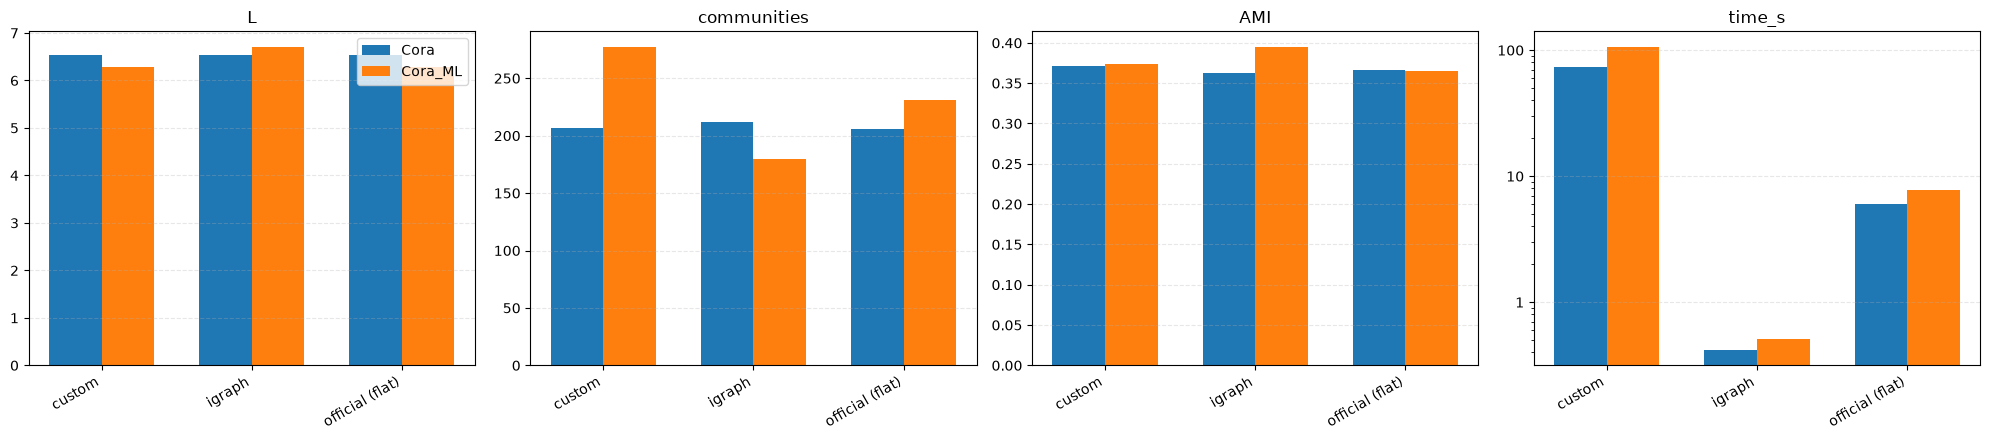

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker


metrics = ["L", "communities", "AMI", "time_s"]
methods = results["method"].unique()
datasets = ["Cora", "Cora_ML"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

x = np.arange(len(methods))
width = 0.35


for ax, metric in zip(axes, metrics):
    for i, dataset in enumerate(datasets):
        vals = [results[(results["method"] == m) & (results["dataset"] == dataset)][metric].values[0] for m in methods]
        offset = (i - 0.5) * width
        ax.bar(x + offset, vals, width, label=dataset)

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=30, ha="right")
    if metric == "time_s":
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()